In [11]:
import numpy as np
import pandas as pd
import torch

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!ls

In [2]:
import numpy as np

In [4]:
!nvidia-smi

Tue Mar 24 14:36:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:01:00.0 Off |                  Off |
| 30%   24C    P8             22W /  300W |       1MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
result_dir = "../__saved__/results/evaluation/161858_process_datasets.csv"
result_dir = "../__saved__/results/evaluation/161948_compare_role_types.csv"
result_dir = "../__saved__/results/evaluation/161910_process_datasets.csv"
result_dir = "../../__saved__/results/evaluation/0306135414_citation_adagcn.csv"
result_dir = "/home/bini/projects/GDA/Clean_SCGDA/__saved__/results/evaluation/0306135748_airport_adagcn.csv"
# result_dir = "../../__saved__/results/evaluation/0306142826_airport_adagcn.csv"

df1 = pd.read_csv(result_dir)
df1

,micro_f1,macro_f1,source,target,model,seed,train_time,status,cuda_device_index,cuda_allocated_mb,cuda_reserved_mb,cuda_max_allocated_mb,cuda_max_reserved_mb,repeat,cur_time,use_tuned
0,0.712073,0.701474,Citationv1,ACMv9,adgfn,0,34.181865,ok,4,552.317871,1924.0,1524.626465,1924.0,0,61358,2
1,0.717180,0.655365,ACMv9,Citationv1,adgfn,0,31.346930,ok,4,1097.529297,2454.0,2069.544434,2454.0,0,61358,2
2,0.377391,0.302599,Blog2,Blog1,adgfn,0,47.683818,ok,4,739.500000,1368.0,1139.529297,1368.0,0,61359,2
3,0.413674,0.319060,Blog1,Blog2,adgfn,0,47.499059,ok,4,379.312988,1000.0,778.100586,1000.0,0,61400,2
4,0.648855,0.622305,EUROPE,BRAZIL,adgfn,0,15.574386,ok,4,186.392578,272.0,204.468750,272.0,0,61400,2
5,0.320802,0.203732,BRAZIL,EUROPE,adgfn,0,15.976376,ok,4,2.292969,38.0,20.746094,38.0,0,61401,2
6,0.686859,0.681926,Citationv1,ACMv9,adagcn,0,19.495311,ok,4,553.217773,1736.0,1515.714355,1736.0,0,61401,2
7,0.758030,0.719168,ACMv9,Citationv1,adagcn,0,19.732020,ok,4,1097.517578,2262.0,2059.821289,2262.0,0,61401,2
8,0.393478,0.355850,Blog2,Blog1,adagcn,0,24.682593,ok,4,739.487305,1250.0,1082.343750,1250.0,0,61402,2
9,0.355663,0.327474,Blog1,Blog2,adagcn,0,26.953618,ok,4,379.632812,918.0,722.037109,918.0,0,61402,2


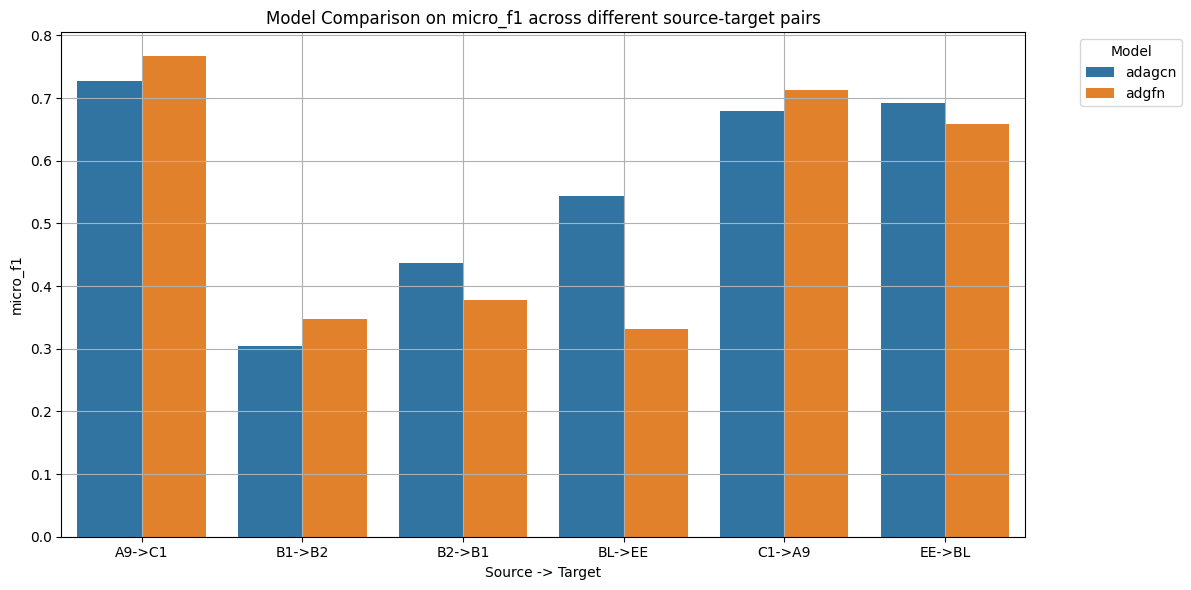

In [13]:
metrics = ["micro_f1", "macro_f1"]
plot_metric = metrics[0]  # choose metric to plot

df1["s->t"] = df1["source"].str[0] + df1["source"].str[-1] + "->" + df1["target"].str[0] + df1["target"].str[-1]

# let's compare each model on each s->t (group by s->t and model)
grouped_df1 = df1.groupby(["s->t", "model"])[plot_metric].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_df1, x="s->t", y=plot_metric, hue="model")
plt.title(f"Model Comparison on {plot_metric} across different source-target pairs")
plt.ylabel(plot_metric)
plt.xlabel("Source -> Target")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

Summary Table (Mean ± Std across seeds):


,s->t,model,micro_f1_mean,micro_f1_std,macro_f1_mean,macro_f1_std
0,A9->C1,adagcn,0.7267,0.0274,0.6845,0.0300
1,A9->C1,adgfn,0.7666,0.0431,0.7297,0.0647
2,B1->B2,adagcn,0.3046,0.0493,0.2374,0.0781
3,B1->B2,adgfn,0.3481,0.0588,0.2709,0.0417
4,B2->B1,adagcn,0.4370,0.0719,0.3944,0.0838
5,B2->B1,adgfn,0.3786,0.0032,0.2885,0.0123
6,BL->EE,adagcn,0.5430,0.0088,0.5057,0.0075
7,BL->EE,adgfn,0.3317,0.0113,0.2206,0.0214
8,C1->A9,adagcn,0.6801,0.0120,0.6595,0.0334
9,C1->A9,adgfn,0.7122,0.0052,0.7057,0.0109


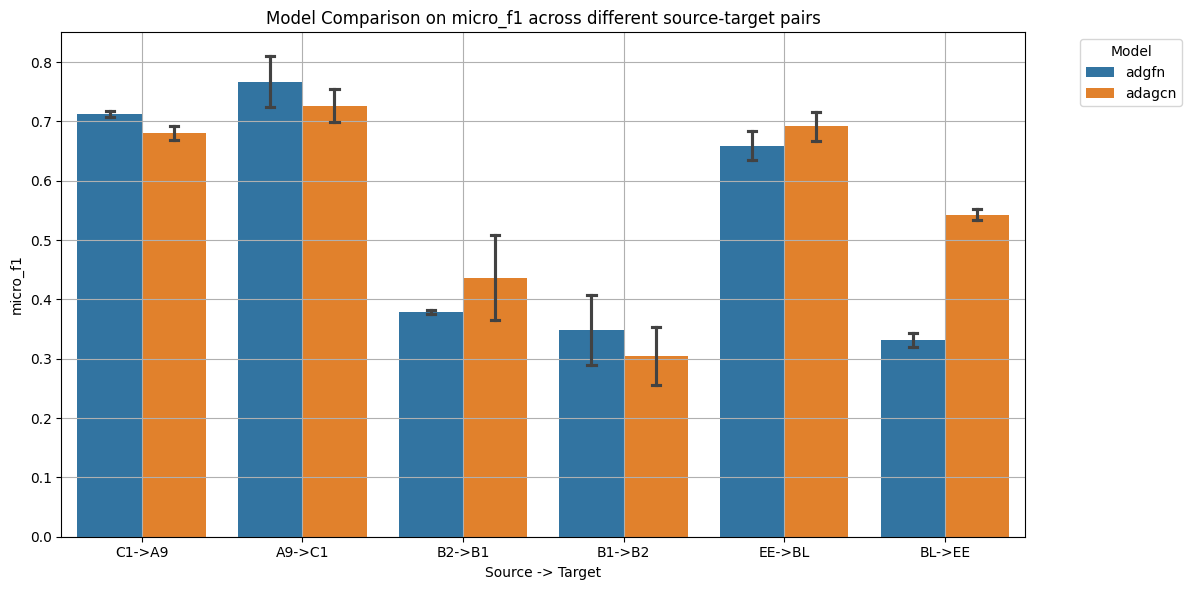

In [14]:
metrics = ["micro_f1", "macro_f1"]
plot_metric = metrics[0]  # choose metric to plot

df1["s->t"] = df1["source"].str[0] + df1["source"].str[-1] + "->" + df1["target"].str[0] + df1["target"].str[-1]

# Create summary table with mean and std for each metric
summary_table = df1.groupby(["s->t", "model"]).agg(
    {m: ["mean", "std"] for m in metrics}
).round(4)

# Flatten column names
summary_table.columns = [f"{m}_{stat}" for m, stat in summary_table.columns]
summary_table = summary_table.reset_index()

print("Summary Table (Mean ± Std across seeds):")
display(summary_table)

# Create grouped data for plotting
grouped_df1 = df1.groupby(["s->t", "model"])[plot_metric].agg(["mean", "std"]).reset_index()

# Plot with error bars
plt.figure(figsize=(12, 6))
sns.barplot(data=df1, x="s->t", y=plot_metric, hue="model", errorbar="sd", capsize=0.1)
plt.title(f"Model Comparison on {plot_metric} across different source-target pairs")
plt.ylabel(plot_metric)
plt.xlabel("Source -> Target")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

In [15]:
# [-1, 2, 1, 10]
# label_diffusion = 4xk
# let's say you have 4 classes, [0.1, 0.2, 0.1, 0.6] 
# x = [1, 0] [0, 1], [0, 1] [0, 1], [0, 1]

# logits = f(x, a)

# argmax = np.argmax(label_diffusion[0])
# role = label_diffusion[argmax, :] # 1xk
